## Clasificador con Catboost

### Descripcion
En esta notebook se entrena un modelo Catboost para predecir `DAMAGE_CLASS` con optimizacion de hiperparametros utilizando Optuna.

### Resumen
Se cargaron los datos obtenidos en las etapas anteriores, que ya cuentan con su respecitva limpieza y procesamiento. Se recuerda que en Catboost, las features categoricas no deben ser codificadas y las variables numericas no necesariamente deben estar escaladas.

Para la seleccion de Hiperparametros se fijo `"auto_class_weights": "Balanced"` y
`"eval_metric": "TotalF1:average=Macro"` debido al desbalance de clases y se utilizo como metrica del estudio Optuna al F1 score Macro.

Con los hiperparametros que mejores resultados arrojaron, se entreno el modelo y se obtuvo una `accuracy` de 0,79 que a priori parece un buen resultado, pero metricas como `f1 macro` de 0,48 nos indican que tenemos algunos inconvenintes.

Estos resultados dispares se entienden mejor al observar la matriz de confusion y las metricas por clase, donde vemos como el modelo tiene valores aceptables para las clases 0 y 1, mientras que para las clases 2, 3 y 4 no.

In [ ]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [2]:
# ---------------------------------------------------------
# 1. Carga de datos
# ---------------------------------------------------------

DATA_PATH = 'processed_datasets/'
X_TRAIN_PATH = DATA_PATH + 'X_train_catboost.parquet'
X_VAL_PATH = DATA_PATH + 'X_val_catboost.parquet'
X_TEST_PATH = DATA_PATH + 'X_test_catboost.parquet'

Y_TRAIN_PATH = DATA_PATH + 'y_train.csv'
Y_VAL_PATH = DATA_PATH + 'y_val.csv'
Y_TEST_PATH = DATA_PATH + 'y_test.csv'

X_train = pd.read_parquet(X_TRAIN_PATH, engine="fastparquet")
X_val = pd.read_parquet(X_VAL_PATH, engine="fastparquet")
X_test = pd.read_parquet(X_TEST_PATH, engine="fastparquet")

y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_val = pd.read_csv(Y_VAL_PATH).squeeze()
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}\n")

categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
#Agregamos dia de la semana al ser categorica pero estar codificada con numeros
categorical_features.extend(['DAY_OF_WEEK'])
print(f"Detected {len(categorical_features)} categorical features: {categorical_features}")

Train shapes: X=(876565, 32), y=(876565,)
Validation shapes: X=(156915, 32), y=(156915,)
Test shapes: X=(115998, 32), y=(115998,)

Detected 11 categorical features: ['EVENT_TYPE', 'CZ_TYPE', 'STATE', 'REGION', 'WFO', 'SOURCE', 'SEASON', 'TIME_OF_DAY', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'DAY_OF_WEEK']


In [3]:
# ---------------------------------------------------------
# 2.Definimos el estudio Optuna
# ---------------------------------------------------------
static_params = {
    "random_seed": 42,
    "verbose": False,
    "task_type": "GPU",
    "auto_class_weights": "Balanced",
    "eval_metric": "TotalF1:average=Macro"
}

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
    }
    params.update(static_params)
    model = CatBoostClassifier(**params)

    model.fit(
        X_train, 
        y_train,
        cat_features=categorical_features,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=100, 
        use_best_model=True
    )

    preds_class = model.predict(X_val)
    preds_class = np.squeeze(preds_class)
    
    # usamos Macro F1
    macro_f1 = f1_score(y_val, preds_class, average='macro')
    
    return macro_f1


In [4]:
# ---------------------------------------------------------
# 3. Corremos el estudio
# ---------------------------------------------------------

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Mejor macro-f1: {study.best_value:.4f}")
print("Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-20 11:29:38,975] A new study created in memory with name: no-name-a2181de8-f1f7-4733-bede-97ae78009344
[I 2026-06-20 11:31:15,963] Trial 0 finished with value: 0.4623247803627543 and parameters: {'iterations': 1090, 'learning_rate': 0.011200886576806977, 'depth': 9, 'l2_leaf_reg': 9.250190106411326, 'min_data_in_leaf': 27}. Best is trial 0 with value: 0.4623247803627543.
[I 2026-06-20 11:32:35,707] Trial 1 finished with value: 0.3923519157227658 and parameters: {'iterations': 1407, 'learning_rate': 0.0020199231282575433, 'depth': 10, 'l2_leaf_reg': 1.6786276379139196, 'min_data_in_leaf': 46}. Best is trial 0 with value: 0.4623247803627543.
[I 2026-06-20 11:32:49,852] Trial 2 finished with value: 0.3746351605474957 and parameters: {'iterations': 1962, 'learning_rate': 0.0017935337024872712, 'depth': 9, 'l2_leaf_reg': 8.861763858641158, 'min_data_in_leaf': 45}. Best is trial 0 with value: 0.4623247803627543.
[I 2026-06-20 11:33:07,529] Trial 3 finished with value: 0.3687013046

Mejor macro-f1: 0.4862
Parameters:
  iterations: 1876
  learning_rate: 0.09744806231676117
  depth: 7
  l2_leaf_reg: 6.902195669363566
  min_data_in_leaf: 2


In [5]:
# ---------------------------------------------------------
# 4. Entrenamos
# ---------------------------------------------------------
final_params = study.best_params.copy()
final_params.update(static_params)
final_model = CatBoostClassifier(**final_params)

final_model.fit(
    X_train, 
    y_train,
    cat_features=categorical_features,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=100,
    use_best_model=True
)

CatBoostClassifier(auto_class_weights='Balanced', depth=7, eval_metric='TotalF1:average=Macro', iterations=1876, l2_leaf_reg=6.902195669363566, learning_rate=0.09744806231676117, min_data_in_leaf=2, random_seed=42, task_type='GPU', verbose=False)

In [6]:
# ---------------------------------------------------------
# 5. Predecimos
# ---------------------------------------------------------
y_pred = final_model.predict(X_test)

In [14]:
# ---------------------------------------------------------
# 6. Medimos
# ---------------------------------------------------------
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.86      0.90     86950
           1       0.62      0.74      0.67     17859
           2       0.28      0.32      0.30      7736
           3       0.20      0.32      0.25      2274
           4       0.21      0.43      0.28      1179

    accuracy                           0.79    115998
   macro avg       0.45      0.53      0.48    115998
weighted avg       0.83      0.79      0.81    115998



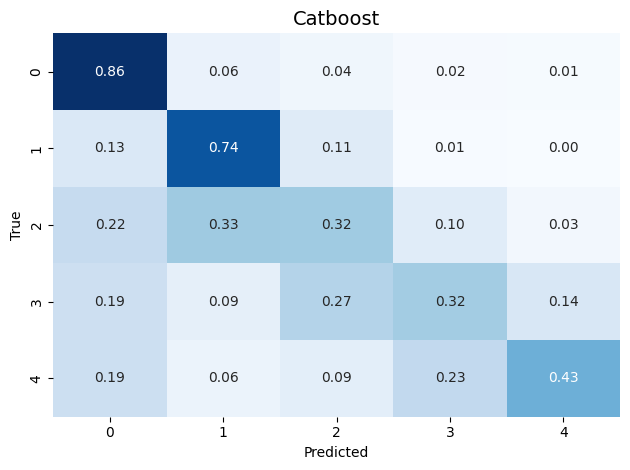

In [8]:
#Matriz de confusion
cm_normal = confusion_matrix(y_test, y_pred,normalize='true')

sns.heatmap(cm_normal, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.title('Catboost', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.show()

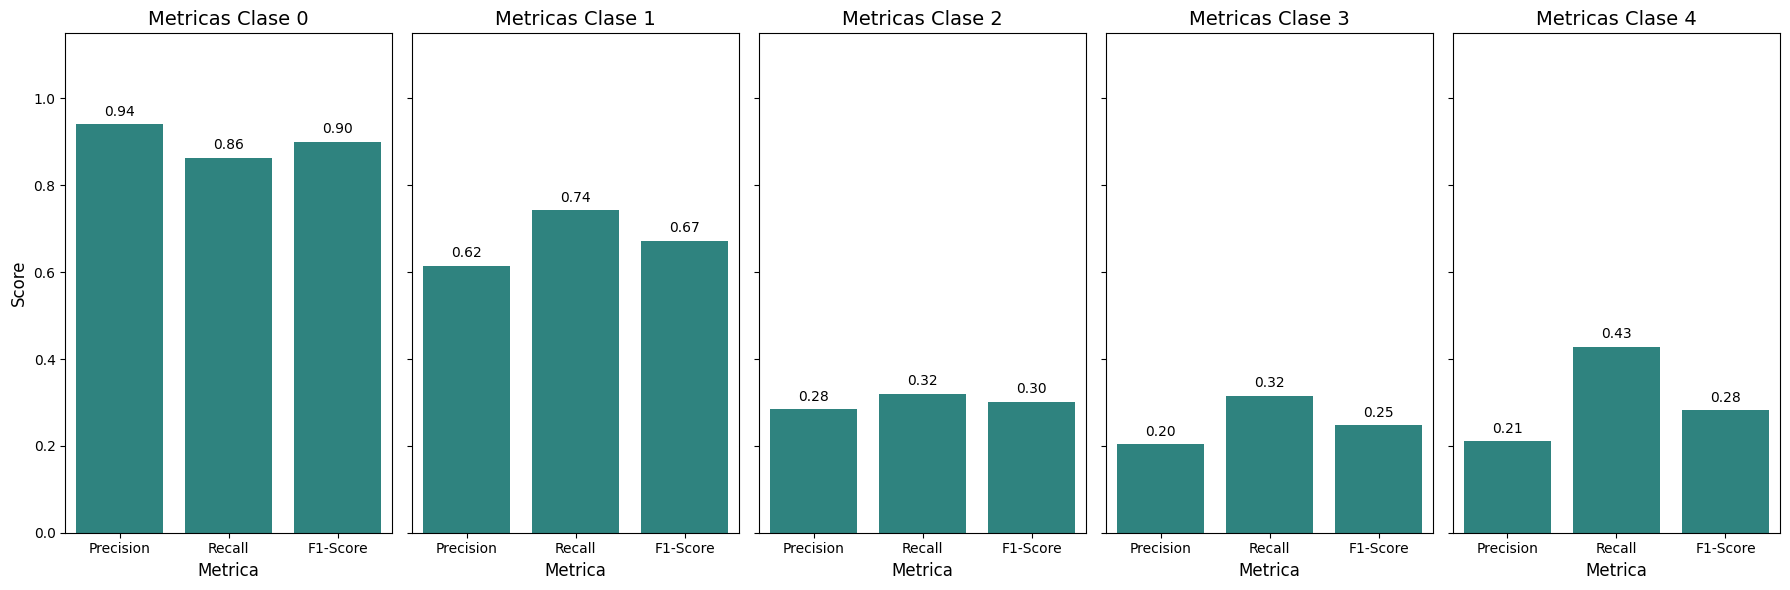

In [ ]:
#Metricas por clase
classes_to_plot = ['0', '1', '2','3','4']
report = classification_report(y_test, y_pred, output_dict=True) 

fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

for i, target_class in enumerate(classes_to_plot):
    data = [
        {'Model': 'Normal', 
         'Precision': report[target_class]['precision'],
         'Recall': report[target_class]['recall'],
         'F1-Score': report[target_class]['f1-score']},
    ]
    
    df_metrics = pd.DataFrame(data)
    df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
    
    sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis', ax=axes[i])
    
    axes[i].set_ylim(0, 1.15)
    axes[i].set_title(f'Metricas Clase {target_class}', fontsize=14)
    axes[i].set_xlabel('Metrica', fontsize=12)
    
    if i == 0:
        axes[i].set_ylabel('Score', fontsize=12)
    else:
        axes[i].set_ylabel('')
        
    axes[i].get_legend().remove()
    
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0: 
            axes[i].annotate(f"{height:.2f}", 
                             (p.get_x() + p.get_width() / 2., height), 
                             ha='center', va='center', 
                             xytext=(0, 9), 
                             textcoords='offset points',
                             fontsize=10)

plt.tight_layout()
plt.show()

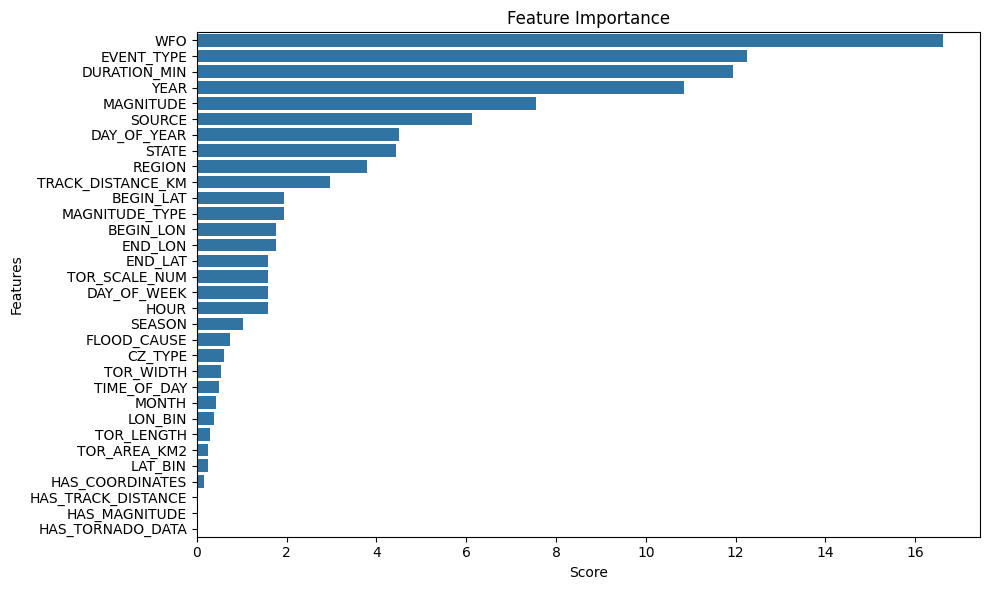

In [21]:
#Feature Importance
importances = final_model.get_feature_importance()
feature_names = final_model.feature_names_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.xlabel('Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [10]:
#Exportamos el modelo
final_model.save_model("catboost_all.cbm")